# Nạp thư viện

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
dataset = pd.read_csv('/content/USA_Housing.csv')
dataset.head(5)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [15]:
dataset.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [17]:
#tách biến độc lập và biến phụ thuộc
dataset.drop(columns=['Address'],inplace=True)
X = dataset.loc[:,['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms','Avg. Area Number of Bedrooms','Area Population']]
y = dataset.loc[:,['Price']]


## Chia dữ liệu thành tập huấn luyện và kiểm thử

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25, random_state = 0)
print(X_train.shape)

(3750, 5)


## Huấn luyện mô hình hồi quy

In [21]:
#c1 sử dụng thư viên
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)


LinearRegression()

In [22]:
w0 = regressor.intercept_
w = regressor.coef_
print(w0)
print(w)

[-2644850.06945536]
[[2.16645980e+01 1.65789776e+05 1.20587850e+05 1.43198844e+03
  1.52483144e+01]]


In [26]:
y_hat = regressor.predict([[79545.458574,	5.682861,	7.009188,	4.09,	23086.800503]])
print(y_hat)

[[1223745.09908627]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Đánh giá mô hình

In [27]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [28]:
y_pred = regressor.predict(X_test)

In [29]:
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))



10401275405.85894
0.918508746677805
81832.71748622792
101986.64327184683


In [30]:
#so sánh RMSR với mean của y_test(y thực tế của tập dữ liệu)
print(np.sqrt(mean_squared_error(y_test,y_pred)),np.mean(y_test))

101986.64327184683 1238824.9185011599


In [31]:
101986.64327184683 / 1238824.9185011599


0.08232530824068288

# Vẽ biểu đồ distribute plot của y_test và y_predict

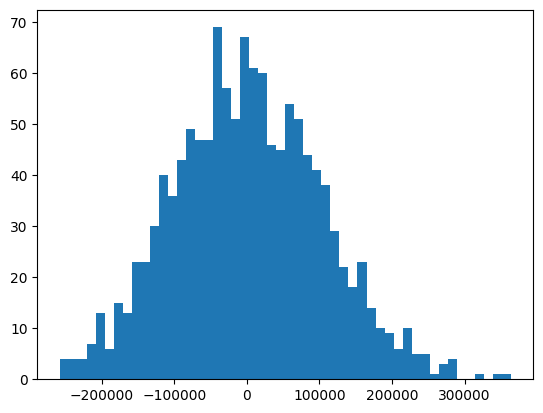

In [33]:
plt.hist(y_test - y_pred,bins = 50)
plt.show()